Testing the processing logic for a single file(Xray, center, azimuthal)

In [36]:
import sys
import os
# Get the current working directory (where the notebook is running)
current_dir = os.getcwd()
# Go up one level to project root (adjust based on your structure)
project_root = os.path.dirname(current_dir)
sys.path.insert(0, project_root)

In [47]:
from pathlib import Path
from src.processor.expdir_processor import DirectoryProcessor
from src.processor.processor_objects import XPSGroupProcessor
from src.processor.tiff_objects import EMCCDimage
from src.plots.quick_plot import plot_ndarray
from src.io.tiff_SL import load_tiff_single
from src.masks.mask_class import precompute_center_masks, precompute_radial_masks, precompute_azimuthal_average_masks
from src.utils.xps_value_sort import group_tiff_files_with_info
import numpy as np

In [48]:
Result_folder = Path(r"C:\Users\ab177\Desktop\diffraction_results\0926")
Expdata_folder = Path(r"E:\20250926\3_longscan5_44deg\fist_AndorEMCCD")

background_path = Result_folder / "background.tiff"
background_data = load_tiff_single(background_path)
print(f"Loaded background from: {background_path}")

Loaded background from: C:\Users\ab177\Desktop\diffraction_results\0926\background.tiff


In [75]:
ring_mask = precompute_center_masks(
    image_shape=(1440,1440),
    inner_radius=30, 
    outer_radius=80
)

# Initialize radial masks
radial_masks = precompute_radial_masks(
    image_shape=(1440,1440),
    radius=720, 
    num_bins=720
)

# Initialize azimuthal mask dictionary
azimuthal_mask_dict = precompute_azimuthal_average_masks(radial_masks)

In [40]:
Preprocessor = DirectoryProcessor(
    result_directory= Result_folder,
    data_directory= Expdata_folder,
    xps_grouping_param= [],
    xray_removal_param= [15,0.7],
    center_fitting_param= [80,100,562,512],
    azimuthal_avg_param= [512,512],
    background_directory= "default",
    data_mask_directory= "default"
)
Preprocessor.initialize_bkg_and_datamask()
xps_value, filelist = Preprocessor.select_test_xps_group_numbered(group_size=200)[0]

2026-01-13 18:38:27,531 - INFO - Initializing background and data mask...
2026-01-13 18:38:27,541 - INFO - Loaded background from: C:\Users\ab177\Desktop\diffraction_results\0926\background.tiff
2026-01-13 18:38:27,544 - INFO - Default data mask file not found under: C:\Users\ab177\Desktop\diffraction_results\0926\background.tiff, proceed without masking!
2026-01-13 18:38:27,554 - INFO - Numbered test XPS group selection...



SELECT TEST XPS GROUP
 1. XPS 221.15750: 1540 files
 2. XPS 220.85750: 1530 files
 3. XPS 221.30750: 1530 files
 4. XPS 220.88750: 1504 files
 5. XPS 220.90250: 1460 files
 6. XPS 220.91750: 1440 files
 7. XPS 220.93250: 1430 files
 8. XPS 221.03750: 1430 files
 9. XPS 220.96000: 1420 files
10. XPS 220.94000: 1400 files
11. XPS 221.00750: 1400 files
12. XPS 221.01375: 1390 files
13. XPS 221.03500: 1390 files
14. XPS 221.00500: 1380 files
15. XPS 220.98375: 1370 files
16. XPS 220.99000: 1370 files
17. XPS 221.03125: 1310 files
18. XPS 220.99875: 1290 files
19. XPS 221.01625: 1290 files
20. XPS 221.02875: 1260 files
21. XPS 220.87125: 1240 files
22. XPS 220.99250: 1230 files
23. XPS 220.95375: 1130 files
24. XPS 220.97750: 1100 files
25. XPS 220.96500: 1080 files
26. XPS 221.02250: 1060 files
27. XPS 220.98000: 1000 files
28. XPS 221.02000:  990 files
29. XPS 221.02500:  950 files
30. XPS 220.99500:  910 files
31. XPS 220.97125:  900 files
32. XPS 220.98625:  870 files
33. XPS 220.94750

In [83]:
TestProcessor = XPSGroupProcessor(
    background_data=background_data,
    data_mask_data=Preprocessor.data_mask_data,
    X_ray_config=[15, 0.7],  # [beam_threshold, expansion_threshold_ratio]
    center_config=[ring_mask, [920, 930]],  # [inner_radius, outer_radius, center_x, center_y]
    azimuthal_config=[radial_masks, azimuthal_mask_dict],  # [radius, num_bins]
    xps_value=xps_value, 
    filelist=filelist,
    resultdir=Result_folder
)
TestProcessor.precompute_xray_statistics()

2026-01-13 19:26:09,298 - INFO - Randomly sampled 50 files for X-ray statistics precomputation
2026-01-13 19:26:20,278 - INFO - X-ray statistics precomputation completed. Center region (40x40) excluded.


Plotting background used:

DEBUG PROCESSING: background.tiff
Under:C:\Users\ab177\Desktop\diffraction_results\test

1. ORIGINAL DATA:


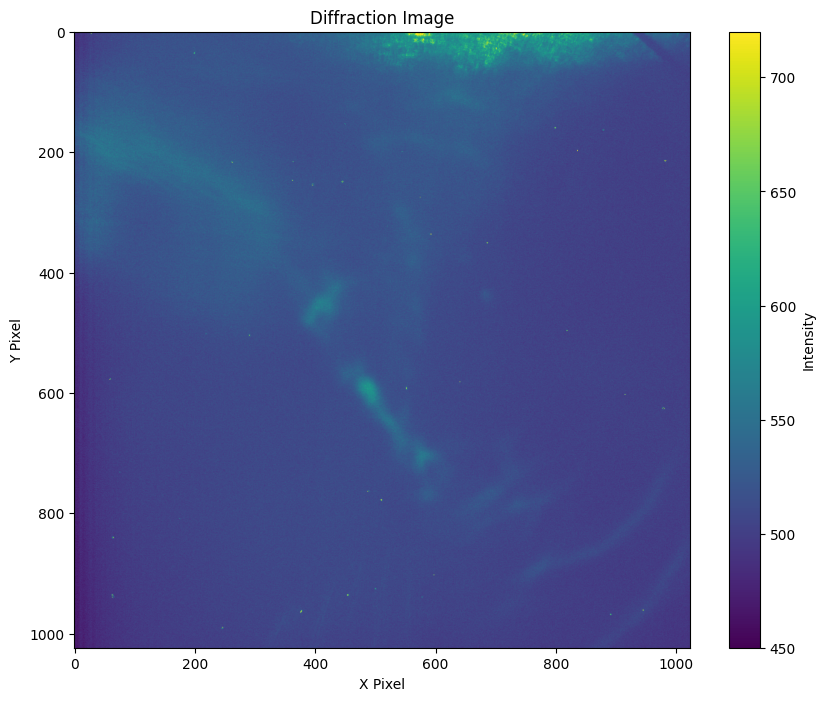


2. BACKGROUND REMOVAL:
After background removal:
NaN count: 25


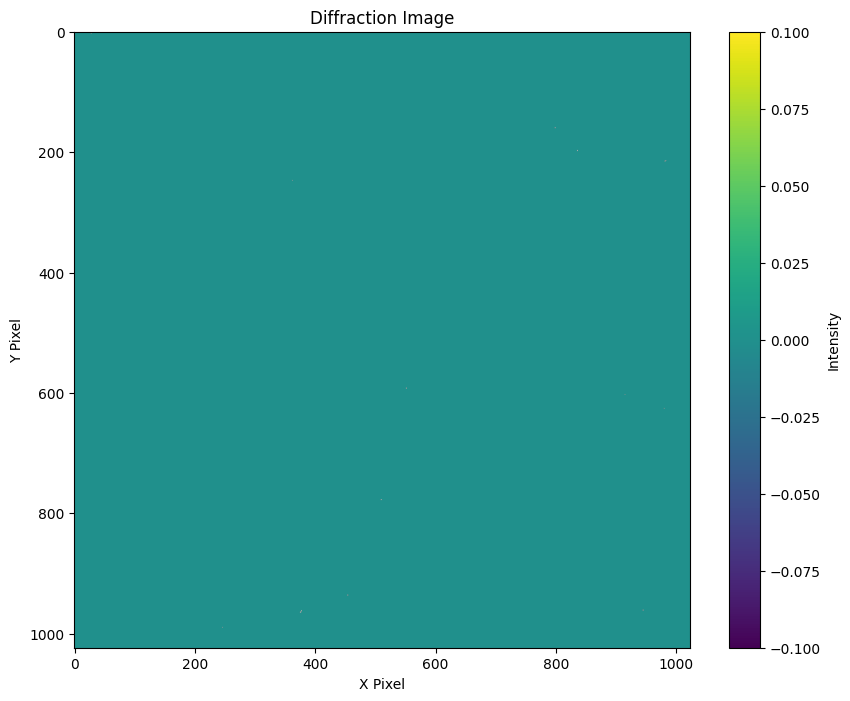


3. MASKING DATA:
After data masking:


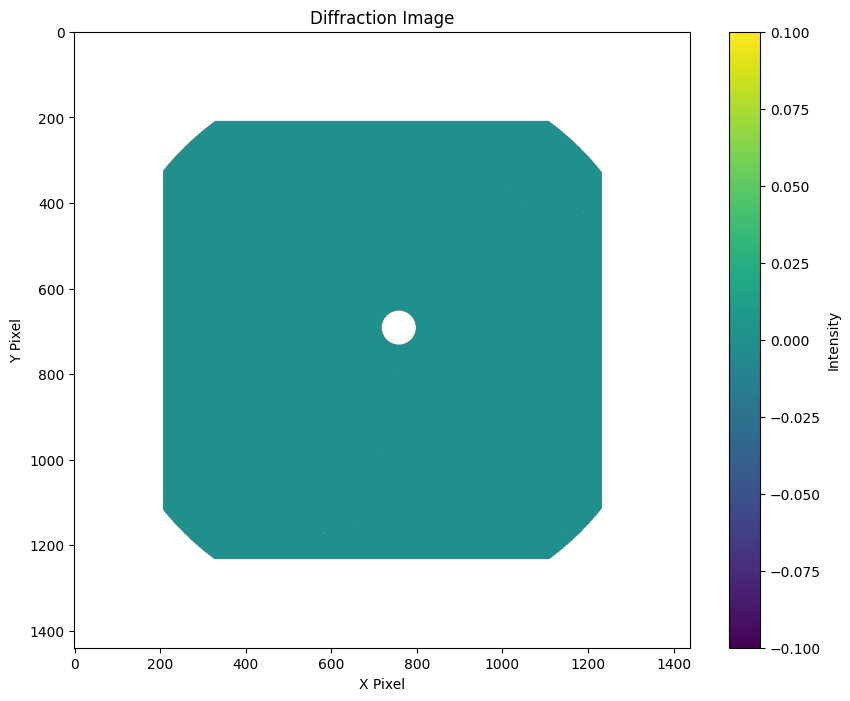


4. CENTER FINDING:
Found center: (712.00, 722.00)

5. AZIMUTHAL AVERAGE:
Radial profile range: [0.000, 0.000]
Non-NaN bins: 720/720


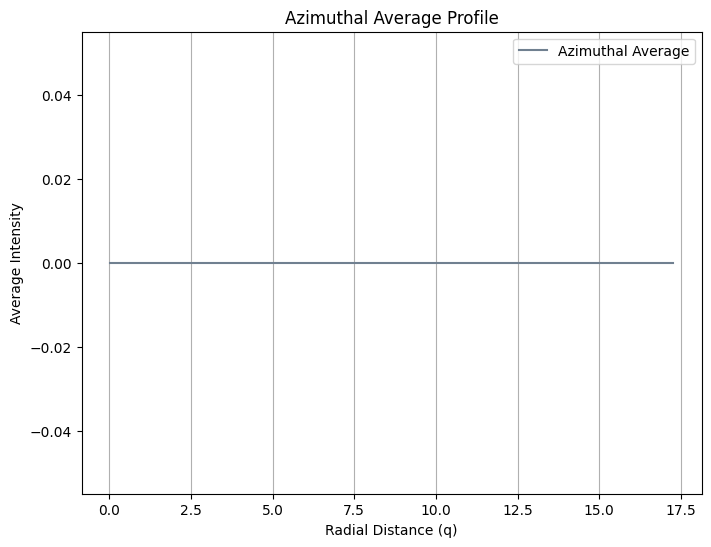


✓ SUCCESSFULLY PROCESSED: background.tiff


In [84]:
print('Plotting background used:')
TestProcessor.process_single_debug(r'C:\Users\ab177\Desktop\diffraction_results\test\background.tiff',450,720,0,0,1440)


DEBUG PROCESSING: AndorEMCCD-12397_xps221.157500_scan36_labtime00-33-24p990461.tiff
Under:E:\20250926\3_longscan5_44deg\fist_AndorEMCCD

1. ORIGINAL DATA:


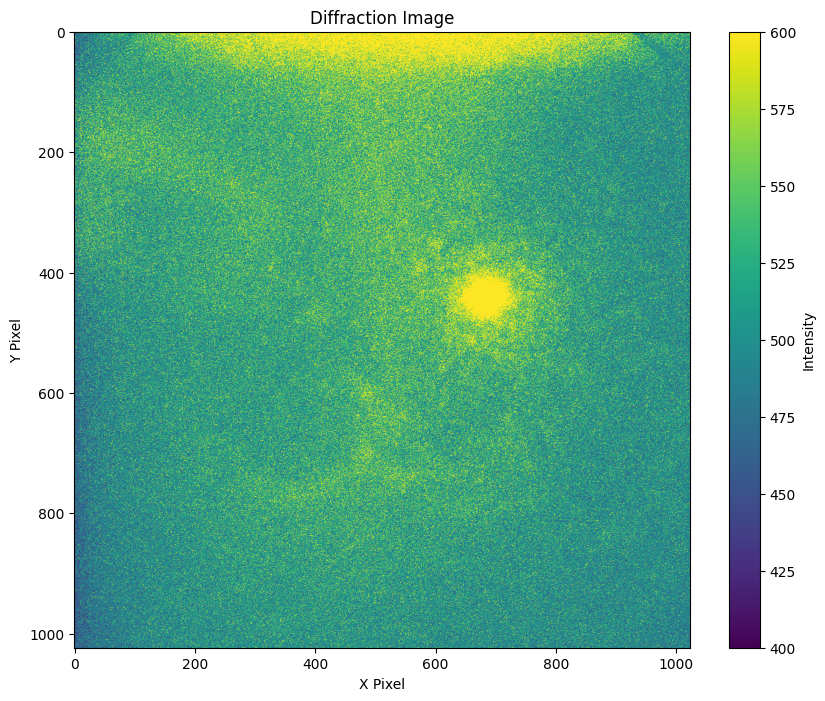


2. BACKGROUND REMOVAL:
After background removal:
NaN count: 26


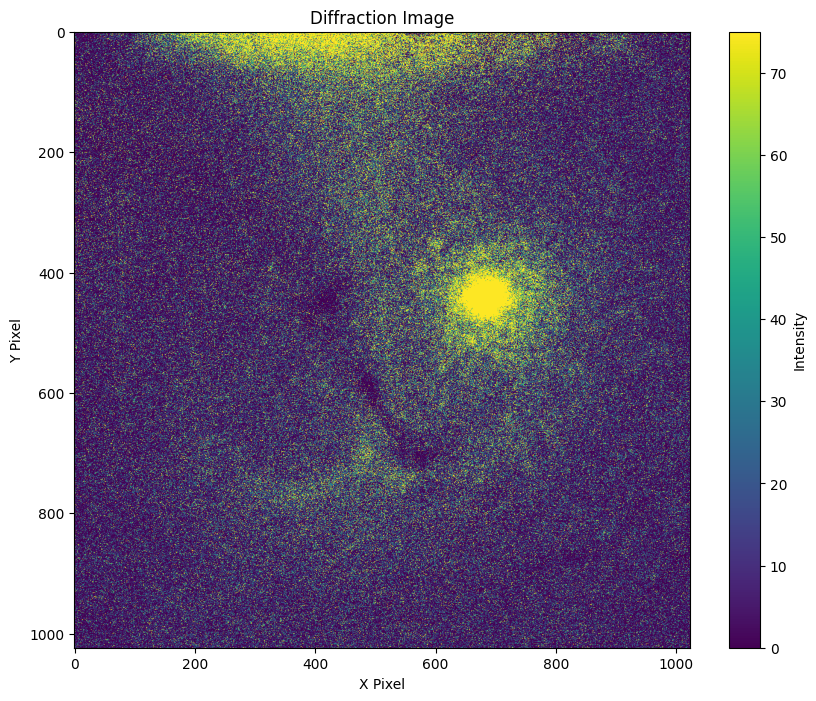


3. MASKING DATA:
After data masking:


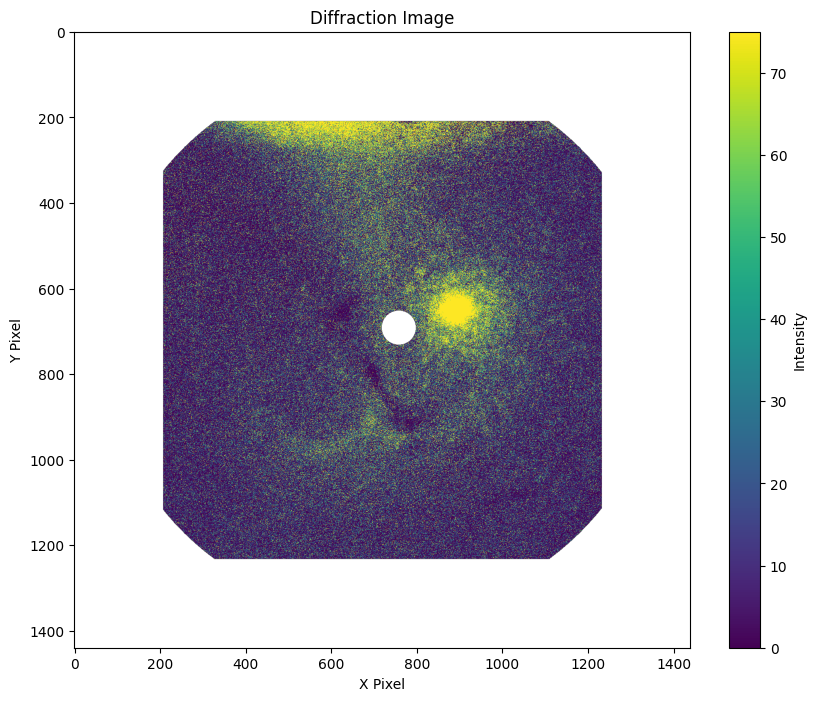


4. CENTER FINDING:
Found center: (681.79, 441.21)

5. AZIMUTHAL AVERAGE:
Radial profile range: [-1.542, 27453.365]
Non-NaN bins: 720/720


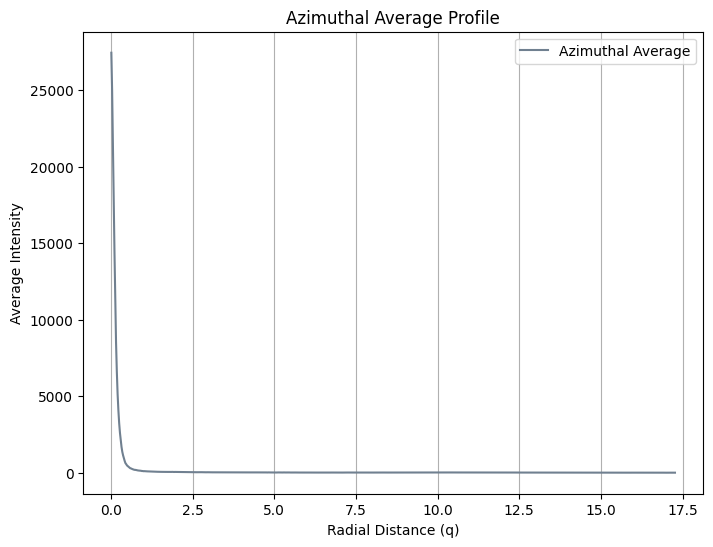


✓ SUCCESSFULLY PROCESSED: AndorEMCCD-12397_xps221.157500_scan36_labtime00-33-24p990461.tiff


In [85]:
TestProcessor.center_config[1] = [905,662]
TestProcessor.process_single_debug(filelist[10],400,600,0,75,1440)

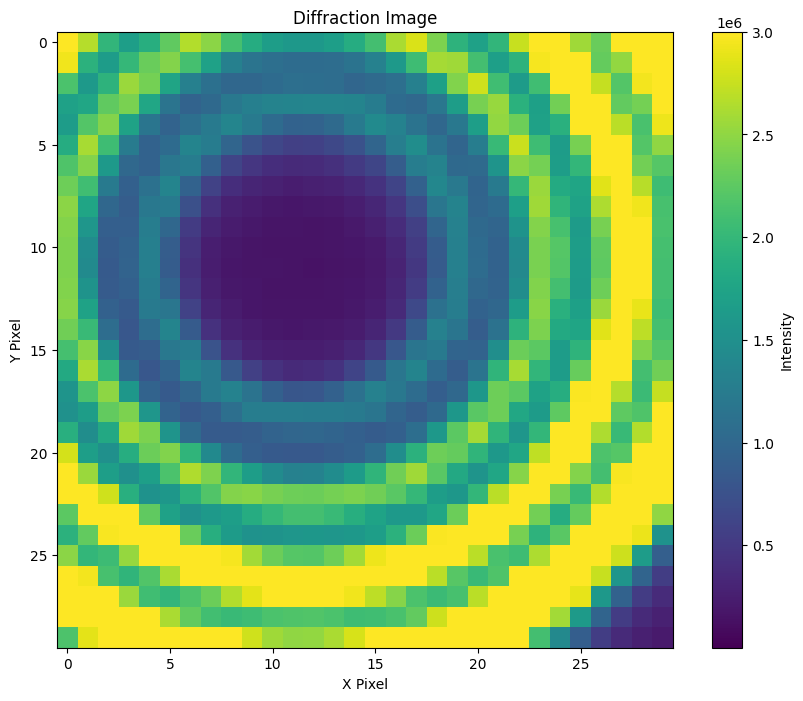

In [76]:
test = EMCCDimage(load_tiff_single(filelist[10]))
test.remove_background_legacy(background_data)
test.apply_data_mask(Preprocessor.data_mask_data,1440)

std_array = []
for i in range(-15,15):
    std_line = []
    for j in range(-15,15):
        std = test.calculate_std_sum_with_masks([700+208+i*4,455+208+j*4],ring_mask)
        std_line += [std]
    std_array += [std_line]


plot_ndarray(std_array,1000,3000000)

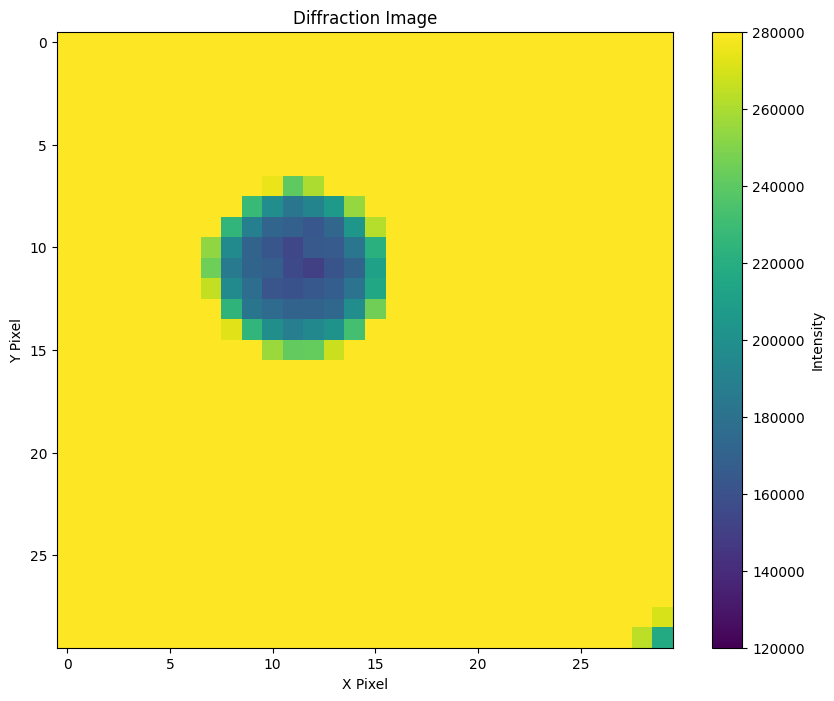

In [78]:
plot_ndarray(std_array,120000,280000)

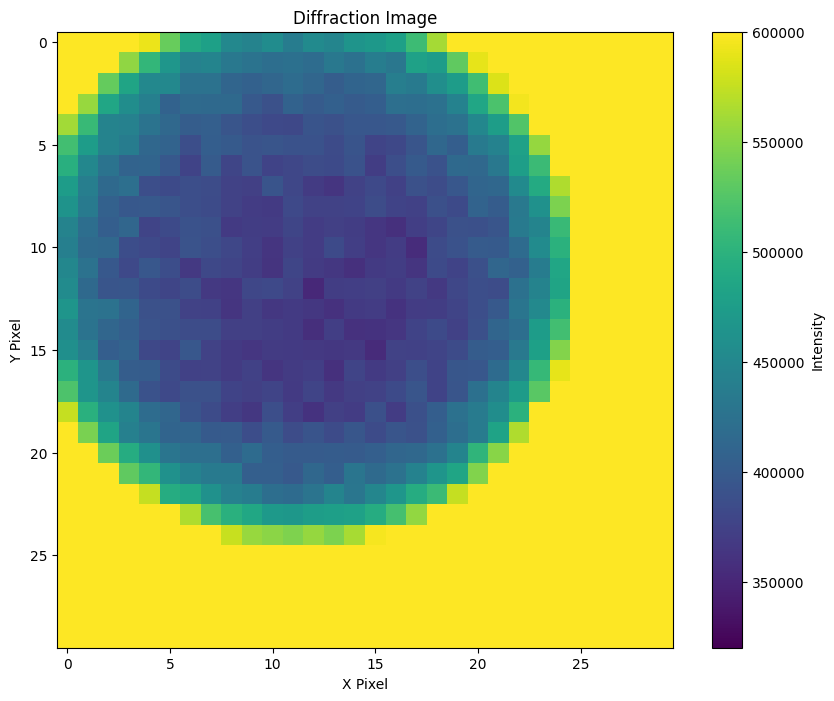

In [ ]:
plot_ndarray(std_array,320000,600000)
#70,120

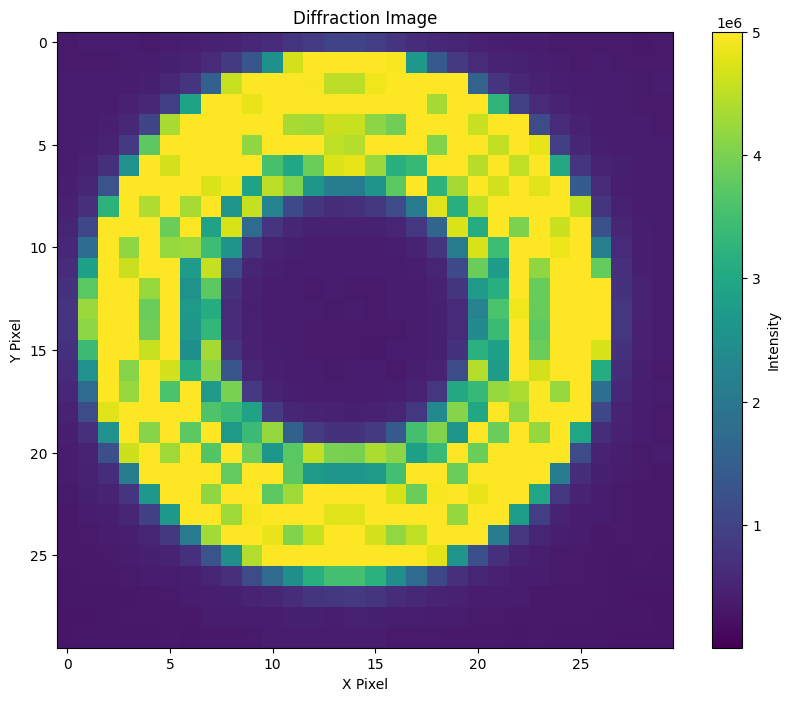

In [58]:
plot_ndarray(std_array,5000,5000000)

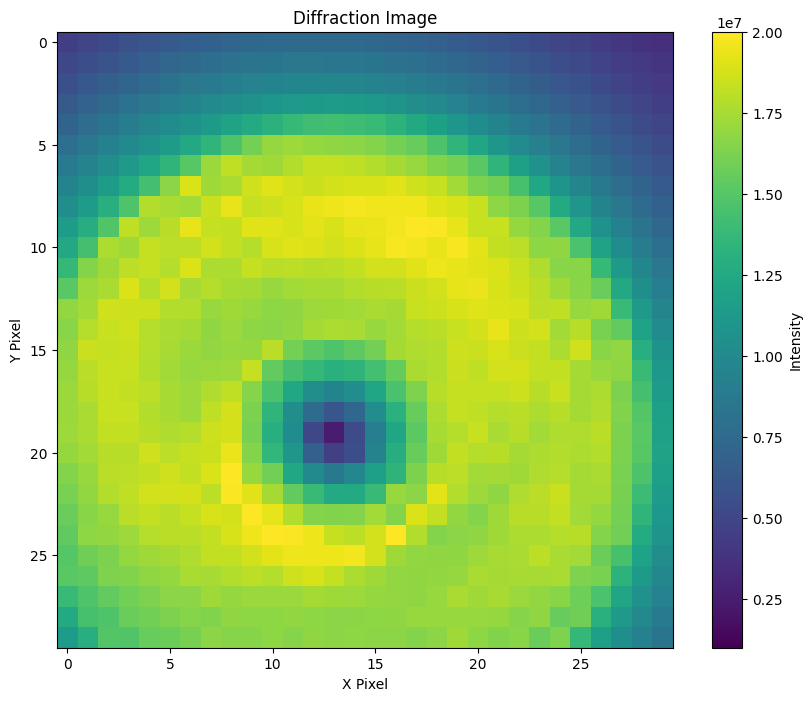

In [31]:
plot_ndarray(std_array,1000000,20000000)

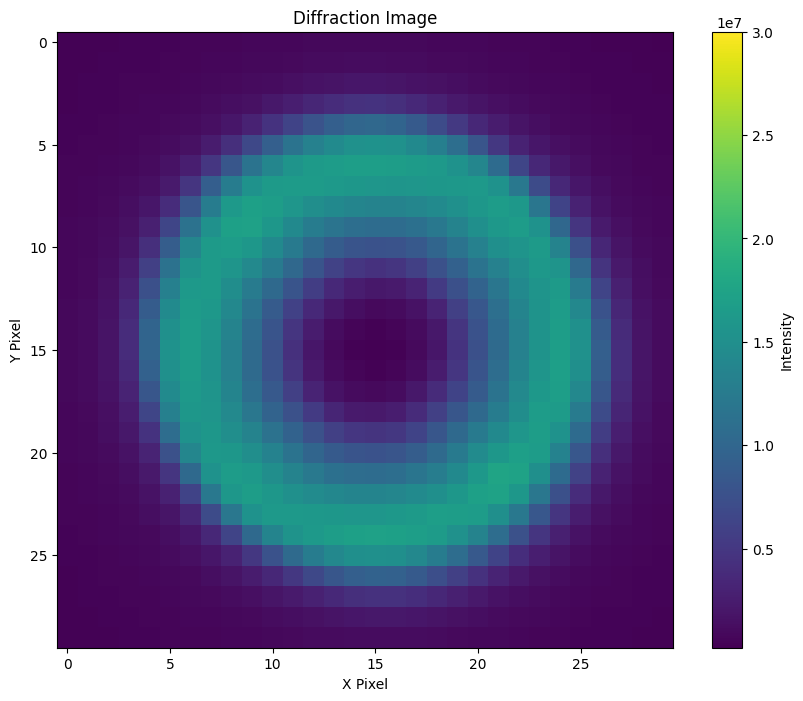

In [32]:
std_array = []
for i in range(-15,15):
    std_line = []
    for j in range(-15,15):
        std = test.calculate_std_sum_with_masks([920+i*10,925+j*10],ring_mask)
        std_line += [std]
    std_array += [std_line]

plot_ndarray(std_array,200000,30000000)

In [41]:
print(std_array[15][15])
print(std_array[14][14])
print(std_array[16][16])

175866.05693908708
646907.5381531706
635267.6840911658
